In [247]:
import nibabel as nib
import numpy as np
import lib_EDT
import matplotlib.pyplot as plt


In [248]:
def get_dice(pred, gt):
    # num is the total number of classes, include the background
    dice = 2*np.sum(pred*gt)/(np.sum(pred+gt))
            
    return dice

In [249]:
def get_wtdice(pred, gt, wts_exp):
    # num is the total number of classes, include the background
    wtdice = 2*np.sum(wts_exp*pred*gt)/np.sum(wts_exp*(pred+gt))
            
    return wtdice

In [255]:
# load() function creates a NiBabel image object from a NIfTI file.
slice_num     = 40
t1_orig       = nib.load('pac_1007_orig.nii.gz')
t1_mask       = nib.load('pac_1007_mask.nii.gz')
t1_depth_info = nib.load('pac_1007_roi_map_EDT_NZNEG.nii.gz')

t1_orig data shape =  (64, 64, 64)
mid_slice_orig shape =  (64, 64)


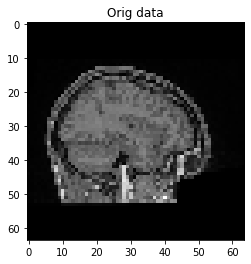

249.0


In [256]:
t1_orig_data = t1_orig.get_fdata()
print('t1_orig data shape = ',(t1_orig_data.shape))
mid_slice_orig = t1_orig_data[slice_num, :, :]
print('mid_slice_orig shape = ',mid_slice_orig.shape)
plt.imshow(mid_slice_orig, cmap='gray')

plt.title('Orig data')
plt.show()
print(mid_slice_orig.max())

t1_mask data shape   =  (64, 64, 64)
mid_slice_mask shape =  (64, 64)


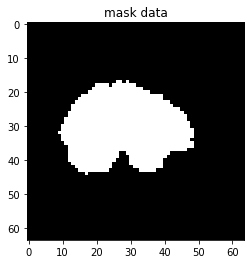

In [257]:
t1_mask_data = t1_mask.get_fdata()
print('t1_mask data shape   = ',(t1_orig_data.shape))
mid_slice_mask = t1_mask_data[slice_num, :, :]
print('mid_slice_mask shape = ',mid_slice_mask.shape)
plt.imshow(mid_slice_mask, cmap='gray')
plt.title('mask data')
plt.show()

t1_depth data shape =  (64, 64, 64)
mid_slice_orig shape =  (64, 64)


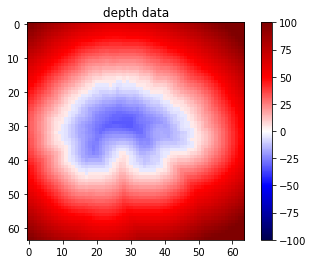

In [258]:
t1_depth_data = t1_depth_info.get_fdata()
print('t1_depth data shape = ',(t1_depth_data.shape))
mid_slice_depth = t1_depth_data[slice_num, :, :]
print('mid_slice_orig shape = ',mid_slice_depth.shape)
plt.imshow(mid_slice_depth, cmap='seismic',vmin = -100, vmax = 100)
plt.title('depth data')
plt.colorbar()
plt.show()

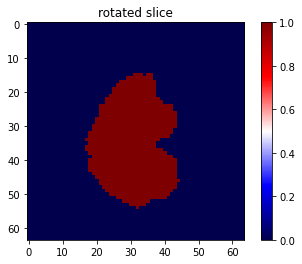

1.0


In [259]:
rotated_slice = np.rot90(mid_slice_mask.squeeze(), 1) 
plt.imshow(rotated_slice, cmap='seismic')
plt.title('rotated slice')
plt.colorbar()
plt.show()

print(rotated_slice.max())

1.0
flr= 0.2643129084460268
(64, 64)
0.9280228006460862


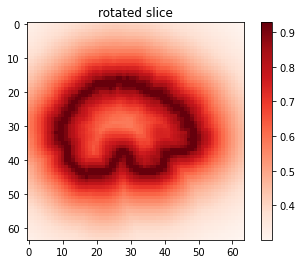

0.9280228006460862
0.3009406119705794


In [260]:
# Normalising the depth_info
wts     = mid_slice_depth/mid_slice_depth.max()
print(wts.max())
#flr = 0.2
dist_scale = 1/3
flr = 0.2*(np.exp(-wts.min()))
print('flr=',flr)
# Exponential(Normalized depth_info)
#wts_exp = np.exp(-1/(100*np.abs(wts)))
#wts_exp = np.exp(-1/(100*np.abs(wts)))
#wts_exp = (np.exp(-3*np.abs(wts)))
#wts_exp = 2* np.ones(np.shape(wts))
wts_abs = np.abs(wts)
wts_exp = (1-flr)*np.exp(-wts_abs/dist_scale)+ flr
print(wts_exp.shape)
print(wts_exp.max())
plt.imshow(wts_exp,  cmap='Reds')
plt.title('rotated slice')
plt.colorbar()
plt.show()
print(wts_exp.max())
print(wts_exp.min())

112.5504150390625
0.0
flr= 0.2
(64, 64)
1.0


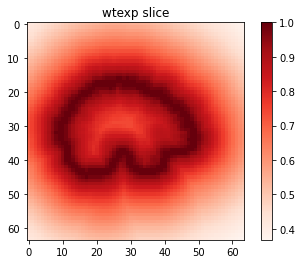

1.0
0.36811747234986597


In [261]:
# Normalising the depth_info # new cell

#wts     = mid_slice_depth/mid_slice_depth.max()
mid_slice_depth_abs =  np.abs(mid_slice_depth)
wts = mid_slice_depth_abs - mid_slice_depth_abs.min()

print(wts.max())
print(wts.min())
flr = 0.2
dist_scale =50
#flr = 0.2*(np.exp(-wts.min()))
print('flr=',flr)
# Exponential(Normalized depth_info)
#wts_exp = np.exp(-1/(100*np.abs(wts)))
#wts_exp = np.exp(-1/(100*np.abs(wts)))
#wts_exp = (np.exp(-3*np.abs(wts)))
#wts_exp = 2* np.ones(np.shape(wts))
wts_exp = (1-flr)*np.exp(-0.693*wts/dist_scale)+ flr
print(wts_exp.shape)
print(wts_exp.max())
plt.imshow(wts_exp,  cmap='Reds')
plt.title('wtexp slice')
plt.colorbar()
plt.show()
print(wts_exp.max())
print(wts_exp.min())

In [262]:
np.log(.5)

-0.6931471805599453

In [263]:
# Calculate dice and wtdice coefficients
print(mid_slice_mask.shape)
slice_dice = get_dice(mid_slice_mask, rotated_slice)
print(slice_dice)

(64, 64)
0.6505867014341591


In [264]:
wtslice_dice = get_wtdice(mid_slice_mask, rotated_slice, wts_exp)
print(wtslice_dice)
#0.6274582947433609 

0.6410395386696648


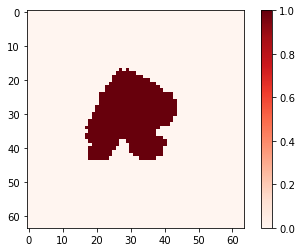

In [192]:
numerator = mid_slice_mask*rotated_slice
plt.imshow(numerator, cmap='Reds')
plt.colorbar()
#plt.title('depth data')
plt.show()

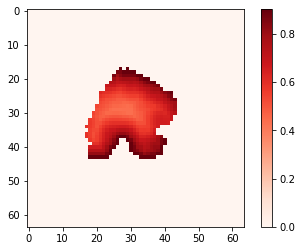

In [193]:
wt_numerator = wts_exp*mid_slice_mask*rotated_slice
plt.imshow(wt_numerator, cmap='Reds')
plt.colorbar()
#plt.title('depth data')
plt.show()

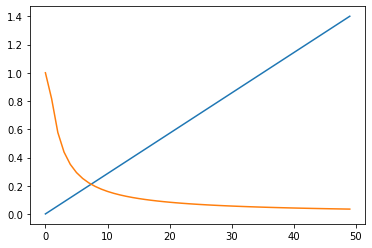

In [182]:
A = np.linspace(0.001, 1.4, num=50)
A_exp = np.exp(-1/(20*A))
plt.plot(A)
plt.plot(1-A_exp)

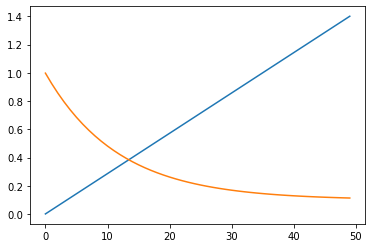

In [218]:
flr = 0.1
dist_scale = 1/3
A_exp2 = (1-flr)*np.exp(-A/dist_scale)+ flr
plt.plot(A)
plt.plot(A_exp2)